# Numpy array vs Python array 

In [58]:
# speed of execution

a = [i for i in range(10000000)]
a1 = [i for i in range(10000000 , 20000000)]

c = []

import time 
start = time.time()

for i in range(len(a)):
    c.append(a[i] + a1[i])
print(time.time() - start)

2.9080286026000977


In [59]:
import numpy as np 

a = np.arange(10000000)
b = np.arange(10000000,20000000)

start = time.time()
c = a + b   # Shows coding i so easy in python   more convinenet  then pyhon list 

print(time.time() - start)

0.28597021102905273


In [60]:
# memory 
a = [i for i in range(10000000)]
import sys

sys.getsizeof(a)


89095160

In [61]:
a = np.arange(10000000 , dtype = np.int32)

sys.getsizeof(a)

40000112

# Advance  indexing 

In [62]:
a = np.arange(24).reshape(6,4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23]])

In [63]:
# Fancy indexing  , pass list  a[[0,2,3]] showing we need 0 row 2 and 3rd

a[[0,2,3]] #fetching 0  2 and 3 row

array([[ 0,  1,  2,  3],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15]])

In [64]:
a[[0,2,3,5]]

array([[ 0,  1,  2,  3],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [20, 21, 22, 23]])

In [65]:
a[:,[0,2,3]] #fetching columns

array([[ 0,  2,  3],
       [ 4,  6,  7],
       [ 8, 10, 11],
       [12, 14, 15],
       [16, 18, 19],
       [20, 22, 23]])

In [66]:
#boolean indexing    | In boolean indexing we use bitwise operator  (& , | etc) 


import random 

a = np.random.randint(1,100,24).reshape(6,4)
a

array([[87, 89, 49, 75],
       [ 5, 43, 46,  7],
       [32, 96,  5, 46],
       [85, 12, 99, 67],
       [78, 65, 90, 25],
       [22, 88, 41, 87]], dtype=int32)

In [67]:
# find all numbers greater than 50

print(a>50 , "\n")
a[a > 50] # result in boolean array it can b used as mask also called boolean masking 


[[ True  True False  True]
 [False False False False]
 [False  True False False]
 [ True False  True  True]
 [ True  True  True False]
 [False  True False  True]] 



array([87, 89, 75, 96, 85, 99, 67, 78, 65, 90, 88, 87], dtype=int32)

In [68]:
# find out even number 

a % 2 == 0

array([[False, False, False, False],
       [False, False,  True, False],
       [ True,  True, False,  True],
       [False,  True, False, False],
       [ True, False,  True, False],
       [ True,  True, False, False]])

In [69]:
a[a % 2 == 0]

array([46, 32, 96, 46, 12, 78, 90, 22, 88], dtype=int32)

In [70]:
[(a % 2 == 0) & (a > 50)] # Mask

[array([[False, False, False, False],
        [False, False, False, False],
        [False,  True, False, False],
        [False, False, False, False],
        [ True, False,  True, False],
        [False,  True, False, False]])]

In [71]:
a[(a % 2 == 0) & (a > 50)] #Value

array([96, 78, 90, 88], dtype=int32)

In [72]:
# Fnd all numbers not divisible by 7 b

a/7 != 0

array([[ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

In [73]:
a[~(a % 7 == 0)]

array([87, 89, 75,  5, 43, 46, 32, 96,  5, 46, 85, 12, 99, 67, 78, 65, 90,
       25, 22, 88, 41, 87], dtype=int32)

# Broadcasting 
### The term broadcasting describe how numpy treats arrays with different shapes during arithmetic operations.The smaller array is "Broadcast" accross the larger array so that they have compatibles shapes

## We can perform  arithmetic operations between two dis-similar  arrays by following some rules these rules are given below in cell  

#### Broadcasting use in methods like vectorization

In [ ]:
a1 = np.arange(6).reshape(2,3)
a2 = np.arange(6,12).reshape(2,3)

print(a1)
print(a2) # Both sapes are same we can apply operaion  


print(a1+a2) 

[[0 1 2]
 [3 4 5]]
[[ 6  7  8]
 [ 9 10 11]]
[[ 6  8 10]
 [12 14 16]]


In [81]:
a1 = np.arange(6).reshape(2,3)
a2 = np.arange(3).reshape(1,3)

print(a1)
print(a2,"\n")

print(a1 + a2)  # This Add due to brodcasting

[[0 1 2]
 [3 4 5]]
[[0 1 2]] 

[[0 2 4]
 [3 5 7]]


# Rules of Broadcasting 
----
- 1. **Make the two arrays have the same number of dimensions.**
 
 
If the numbers of dimensions of the two arrays are different, add new dimensions with size 1 to the head of the array with the
 smaller dimension.

------

- 2. **Make each dimension of the two arrays the same size.**

 If the sizes of each dimension of the two arrays do not match, dimensions with size 1 are stretched to the size of the other
 array.

 If there is a dimension whose size is not 1 in either of the two arrays, it cannot be broadcasted, and an error is raised.

----
- 3. **If dimensions are same but there is no one to increase then broadcasting can't works** 

 Example :-
-  (3,4) (4,3)  dimension same and no one to increase so broadcasting can't work here

----

![NumPy Broadcasting](Broadcasting.jpeg)

In [82]:
# Practice 

a = np.arange(12).reshape(4,3)
a2 = np.arange(3)

print(a,'\n')
print(a2)

[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]] 

[0 1 2]


In [85]:
# Check operators

print(a + a2) # Here addition perform by broadcasting

[[ 0  2  4]
 [ 3  5  7]
 [ 6  8 10]
 [ 9 11 13]]


In [86]:

a = np.arange(12).reshape(3,4)
a2 = np.arange(3)

print(a,'\n')
print(a2)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]] 

[0 1 2]


In [87]:
print(a+a2)

ValueError: operands could not be broadcast together with shapes (3,4) (3,) 

In [91]:
a = np.arange(3).reshape(1,3)
a2 = np.arange(3).reshape(3,1)

print(a, "\n")
print(a2)

[[0 1 2]] 

[[0]
 [1]
 [2]]


In [92]:
print(a + a2)

[[0 1 2]
 [1 2 3]
 [2 3 4]]


In [94]:
a = np.arange(3).reshape(1,3)
a2 = np.arange(4).reshape(4,1)

print(a, "\n")
print(a2)

[[0 1 2]] 

[[0]
 [1]
 [2]
 [3]]


In [95]:
print(a + a2)

[[0 1 2]
 [1 2 3]
 [2 3 4]
 [3 4 5]]


In [96]:
a = np.array([1])

a2 = np.arange(4).reshape(2,2)

print(a,"\n")
print(a2)

[1] 

[[0 1]
 [2 3]]


In [97]:
print(a + a2)

[[1 2]
 [3 4]]


In [ ]:
# Last rule  (Provation of rule 3)

a = np.arange(12).reshape(4,3)
a2 = np.arange(12).reshape(3,4)

print(a, "\n")
print(a2)


[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]] 

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


In [100]:
print(a + a2)

ValueError: operands could not be broadcast together with shapes (4,3) (3,4) 

In [101]:
a = np.arange(16).reshape(4,4)
a2 = np.arange(4).reshape(2,2)

print(a, "\n")
print(a2)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]] 

[[0 1]
 [2 3]]


In [102]:
print(a + a2)

ValueError: operands could not be broadcast together with shapes (4,4) (2,2) 

# Working with mathematical formulas 

In [ ]:
a = np.arange(10)

np.sum(a) # Sum of all numbers of array

np.int64(45)

In [104]:
np.sin(a) #find sin of all digit

array([ 0.        ,  0.84147098,  0.90929743,  0.14112001, -0.7568025 ,
       -0.95892427, -0.2794155 ,  0.6569866 ,  0.98935825,  0.41211849])

# Mathematical function use in ML 

sigmide formula  s(x) = 1 / 1+e^-x  Take all numbers in range of 0 and 1

In [108]:
# Sigmoid

def sigmoid(array):
    return 1/ (1+ np.exp(-(array)))

a = np.arange(9)
sigmoid(a)

array([0.5       , 0.73105858, 0.88079708, 0.95257413, 0.98201379,
       0.99330715, 0.99752738, 0.99908895, 0.99966465])

In [123]:
# mean squared error  loss function that tel u our output change by canging which factor  formulla (orignal - predicted)^2

# MSE = 1/n Sigms (orignal - predicted)^2

actual = np.random.randint(1,50,25)
predicted = np.random.randint(1,50,25)

In [124]:
predicted

array([22,  1, 33,  3, 15, 41, 47, 31, 23, 11, 17, 46, 22, 26, 10,  2, 29,
       17, 20, 10, 23, 10, 37,  9, 11], dtype=int32)

In [125]:
actual

array([31,  4, 37, 20, 44,  5, 20,  2, 14, 34,  4,  4, 47, 30, 25, 36, 35,
       48, 27, 13, 46,  2, 38, 23, 19], dtype=int32)

In [126]:
def mse(actual,predicted):
    return np.mean((actual-predicted)**2)

mse(actual,predicted)

np.float64(423.04)

In [156]:
# working with missing values using ----> np.nan

a = np.array([1,2,4,5,6,np.nan,9])

a

array([ 1.,  2.,  4.,  5.,  6., nan,  9.])

In [ ]:
np.isnan(a)  # Checking each element using  np.isnan 



array([False, False, False, False, False,  True, False])

In [135]:
a[~(np.isnan(a))]  # Removing missing values  

array([1., 2., 4., 5., 6., 9.])

# ploting Graphs  
    Always use np.linspace() function when trying to ploting using python
We can plot any grpah of math  using numpy

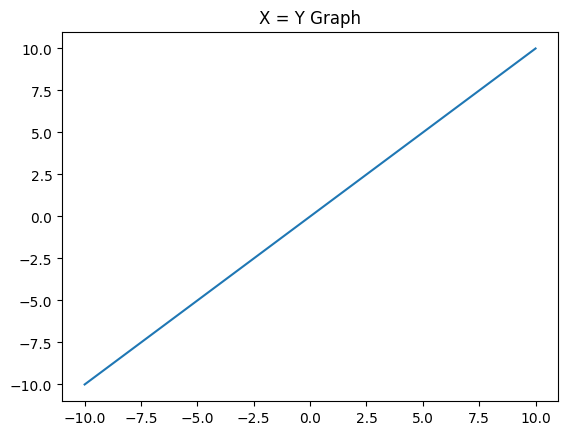

In [141]:
# x = y
import matplotlib.pyplot as plt

x = np.linspace(-10,10,100)
y = x

plt.plot(x,y)
plt.title("X = Y Graph")
plt.show()

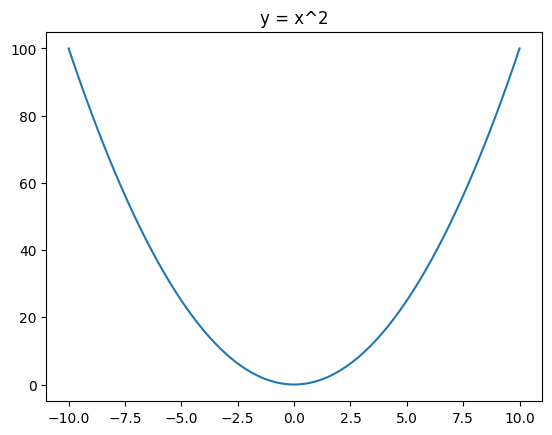

In [143]:
# y = x^2  # graph pf paragola

x = np.linspace(-10,10,100)

y = x**2

plt.plot(x,y)
plt.title("y = x^2")

plt.show()

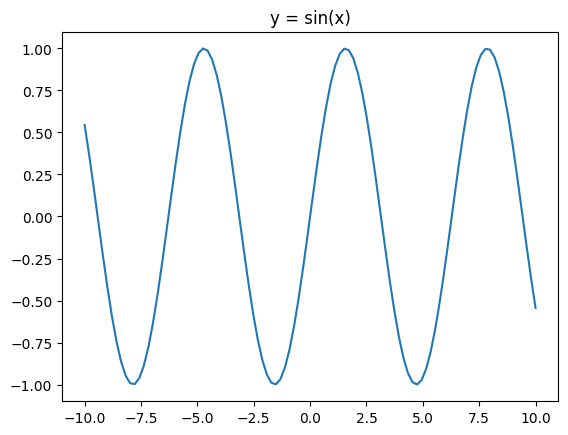

In [145]:
#  y = sin()


x = np.linspace(-10,10,100)

y = np.sin(x)

plt.plot(x,y)
plt.title("y = sin(x)")

plt.show()


C:\Users\zaina\AppData\Local\Temp\ipykernel_21784\3153731254.py:6: RuntimeWarning: invalid value encountered in log
  y = x *( np.log(x))


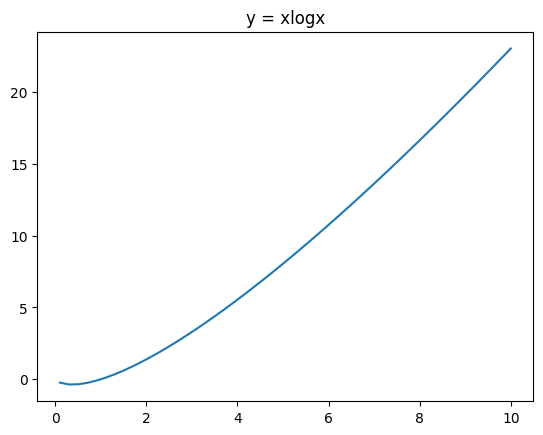

In [ ]:
# y = xlogx


x = np.linspace(-10,10,100)

y = x * ( np.log(x))

plt.plot(x,y)

plt.title("y = xlogx")
plt.show()

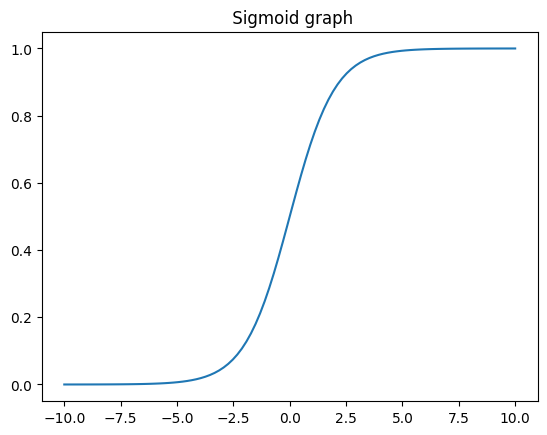

In [155]:
# sigmoid graph

x = np.linspace(-10,10,100)

y = 1 / (1+ np.exp(-x))

plt.plot(x,y)

plt.title(" Sigmoid graph")

plt.show()